## Assignment 1: Multiple Regression

1. Fit a model on 'speed', 'hd', 'ram', and 'screen' and plot the residuals. 
   
   Do any features have unintuitive coefficients? 
   
   Does our model predict better for certain price ranges?  
         
     <br>         
2. Fit a model including all numeric columns (add 'trend' and 'ads' to the previous model), and plot the residuals. 
   
   Do any features have unintuitive coefficients? 
   
   Does our model predict better for certain price ranges?
   
   Which residual plot looks better?

In [6]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

computers = pd.read_csv(r"C:\Users\linke\Desktop\Python\Regressions\Assignments\Assignments\Computers.csv")

computers.tail()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
6254,1690,100,528,8,15,no,no,yes,39,35
6255,2223,66,850,16,15,yes,yes,yes,39,35
6256,2654,100,1200,24,15,yes,no,yes,39,35
6257,2195,100,850,16,15,yes,no,yes,39,35
6258,2490,100,850,16,17,yes,no,yes,39,35


### EDA

In [7]:
computers.corr(numeric_only=True)

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


### First Model

In [10]:
cols = ["ram", "speed", "hd", "screen"]
df = computers

# Features ir target
X = df[['speed', 'hd', 'ram', 'screen']]
y = df['price']

# Pridedam constant (intercept)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     1325.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:29   Log-Likelihood:                -46795.
No. Observations:                6259   AIC:                         9.360e+04
Df Residuals:                    6254   BIC:                         9.363e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3331     88.222      0.117      0.9

In [11]:
# Prognozės
df['predicted_price'] = model.predict(X)

# Residuals
df['residuals'] = y - df['predicted_price']

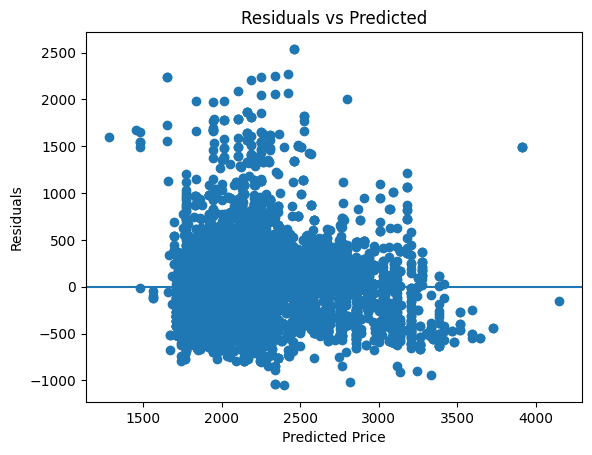

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['predicted_price'], df['residuals'])
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

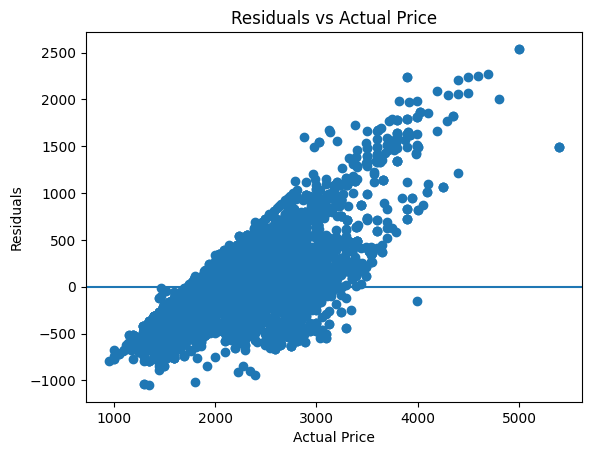

In [13]:
plt.figure()
plt.scatter(df['price'], df['residuals'])
plt.axhline(0)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual Price")
plt.show()

In [14]:
df.groupby(pd.qcut(df['price'], 4))['residuals'].mean()

price
(948.999, 1794.0]   -361.019791
(1794.0, 2144.0]     -82.069486
(2144.0, 2595.0]      73.845586
(2595.0, 5399.0]     379.590720
Name: residuals, dtype: float64

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['speed','hd','ram','screen']]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

  Variable         VIF
0    const  266.587695
1    speed    1.187892
2       hd    2.815748
3      ram    2.561551
4   screen    1.074568


In [16]:
import numpy as np

df['log_price'] = np.log(df['price'])

model_log = sm.OLS(df['log_price'], X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     1332.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:17:17   Log-Likelihood:                 1527.7
No. Observations:                6259   AIC:                            -3045.
Df Residuals:                    6254   BIC:                            -3012.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6953      0.039    171.068      0.0

In [ ]:
# hd has an unintuitive coef - bigger hd value should loggicaly go together with the higher price. 
# It also correlates quite well with ram, but VIF shows normal values, so no significant multicolinearity.
# The model explains 46% of the variation in prices, 
# which is reasonable given the limited number of predictors. 
# All variables are statistically significant and multicollinearity does not 
# appear to be a serious issue. However, additional variables could potentially improve model performance.

### Second Model

In [23]:
cols = ["ram", "speed", "hd", "screen", "ads", "trend"]

# Features ir target
X = df[cols]
y = df['price']

# Pridedam constant (intercept)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     2580.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:05:14   Log-Likelihood:                -44817.
No. Observations:                6259   AIC:                         8.965e+04
Df Residuals:                    6252   BIC:                         8.969e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -246.6755     66.371     -3.717      0.0

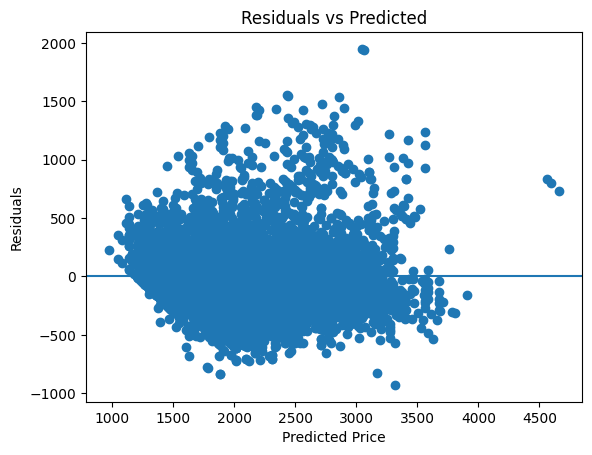

In [24]:
df['predicted_price'] = model.predict(X)
df['residuals'] = df['price'] - df['predicted_price']

plt.scatter(df['predicted_price'], df['residuals'])
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['speed','hd','ram','screen', 'ads', 'trend']]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif 

,Variable,VIF
0,const,283.826581
1,speed,1.257595
2,hd,4.114441
3,ram,2.881423
4,screen,1.078929
5,ads,1.160337
6,trend,1.824542


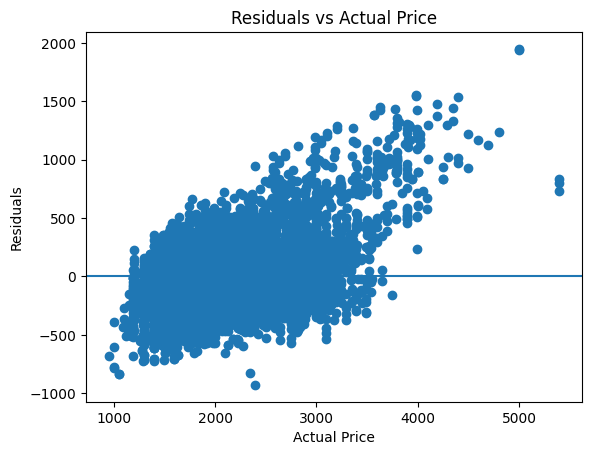

In [29]:
plt.figure()
plt.scatter(df['price'], df['residuals'])
plt.axhline(0)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual Price")
plt.show()

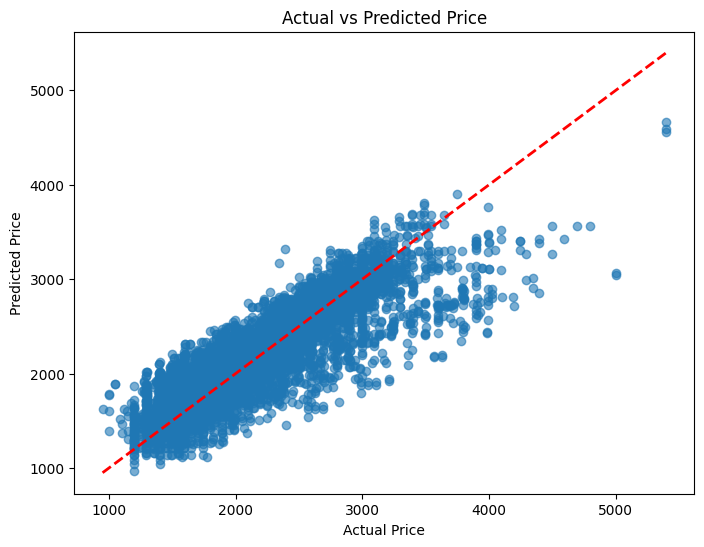

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['price'], df['predicted_price'], alpha=0.6)
plt.plot([df['price'].min(), df['price'].max()],
         [df['price'].min(), df['price'].max()],
         'r--', lw=2)  # 45° linija
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

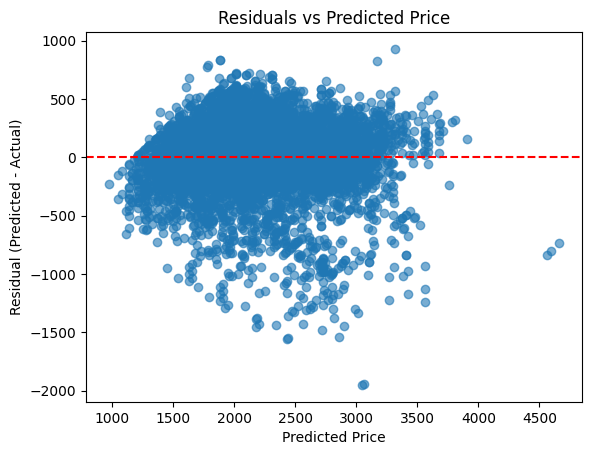

In [31]:
plt.scatter(df['predicted_price'], df['predicted_price'] - df['price'], alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Predicted - Actual)")
plt.title("Residuals vs Predicted Price")
plt.show()

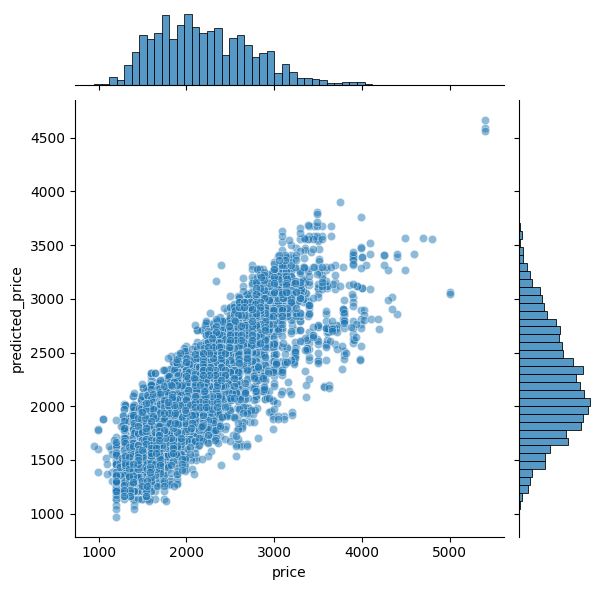

In [32]:
import seaborn as sns
sns.jointplot(x='price', y='predicted_price', data=df, kind='scatter', alpha=0.5)

In [ ]:
#   Even with R² = 0.72, a few extreme high-price outliers can affect residuals and 
# predictions for the most expensive computers. 
# For most of the dataset, the model predicts well, 
# but the outliers may reduce predictive accuracy in the high-price range.

## Assignment 2: Metrics

Calculate MSE and RMSE for your regression model fitted on all numeric features.

In [34]:
from sklearn.metrics import mean_squared_error
import numpy as np

# y_true = tavo tikrosios reikšmės
# y_pred = tavo modelio prognozės

# Naudojame tikrus duomenis, ne stringus
y_true = df['price']            # tikrosios vertės
y_pred = df['predicted_price']  # prognozuotos vertės

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 97033.34029709849
RMSE: 311.5017500706834


In [ ]:
# In human language, the model in average mistaken the prognosis by 311 dolars (each side), or roughly 7-8%.
#It's not bad for a model, especially knowing there were a few sigificant residual outliers (no autocolinearity).
#Adapting the model for a use in a certain price range (no very expensive computers), 
# most likely the RMSE value would go down making the prediction more acurate. 